In [1]:
#!/usr/bin/env python3
"""
stability.py

Compute a simple stability index for a three-pin cranial clamp using:
  • Pin forces F_i [N] from force sensors
  • Pin angular positions θ_i [deg] and lever-arms r_i [m] from 3D tracker markers
  • Friction coefficient μ

Includes:
 1. geometry_from_markers: derive R, θ_i, r_i from tracker
 2. compute_stability_index: torque and S_i
 3. classify_stability: label pins

Formulas:
  r_i       = tracker distance from skull center to pin
  τ_i       = μ * F_i * r_i
  S_i       = τ_i / τ_ref
  τ_ref     = μ * F_ref * R * sin(120°/2)
"""

import numpy as np

def geometry_from_markers(skull_center, pin_markers):
    """
    Compute skull radius R, pin separation angles θ_i, and lever-arms r_i.

    Parameters
    ----------
    skull_center : array-like, shape (3,)
        [x,y,z] of skull-center marker (e.g. centroid).
    pin_markers : list of 3 array-like, each shape (3,)
        [x,y,z] coordinates of each pin-tip marker.

    Returns
    -------
    R_est : float
        Estimated skull radius [m]
    thetas_deg : list of float
        Central angles θ_i (deg) between adjacent pin vectors
    lever_arms : list of float
        r_i = distance from skull_center to each pin [m]
    """
    # vectors from skull center to each pin
    vs = [np.array(p) - np.array(skull_center) for p in pin_markers]
    norms = [np.linalg.norm(v) for v in vs]
    R_est = float(np.mean(norms))

    # compute central angles between each neighboring pair
    thetas = []
    for i in range(3):
        j = (i + 1) % 3
        cos_theta = np.dot(vs[i], vs[j]) / (norms[i] * norms[j])
        theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))
        thetas.append(np.rad2deg(theta))

    return R_est, thetas, norms

def compute_stability_index(R, mu, forces, thetas_deg):
    """
    Compute per-pin torque τ_i and normalized stability S_i.

    Parameters
    ----------
    R : float
        Skull radius [m]
    mu : float
        Friction coefficient [-]
    forces : array-like
        Pin forces F_i [N]
    thetas_deg : array-like
        Pin central angles θ_i [deg]

    Returns
    -------
    torques : np.ndarray
        τ_i = μ * F_i * (R * sin(θ_i/2))  [N·m]
    S : np.ndarray
        S_i = τ_i / τ_ref  [-]
    """
    thetas = np.deg2rad(thetas_deg)
    lever_arms = R * np.sin(thetas / 2)
    torques = mu * np.array(forces) * lever_arms

    # reference: ideal symmetric 120° geometry at same mean force
    theta_ref = np.deg2rad(120)
    F_ref = np.mean(forces)
    r_ref = R * np.sin(theta_ref / 2)
    tau_ref = mu * F_ref * r_ref

    S = torques / tau_ref
    return torques, S

def classify_stability(S, thresholds=(0.8, 1.2)):
    """
    Label each S_i as 'stable', 'marginal', or 'critical'.
    """
    labels = []
    for s in S:
        if s > thresholds[1]:
            labels.append("stable")
        elif s >= thresholds[0]:
            labels.append("marginal")
        else:
            labels.append("critical")
    return labels

if __name__ == "__main__":
    # Example usage with dummy tracker data
    skull_center = [0.0, 0.0, 0.0]  # replace with real tracker centroid
    pin_markers = [                # replace with real marker coords
        [0.1,  0.0,   0.0],
        [-0.05, 0.0866, 0.0],
        [-0.05, -0.0866, 0.0]
    ]
    forces = [100, 100, 100]       # N from force sensors
    mu = 0.3                       # friction coefficient

    # derive geometry
    R, thetas, lever_arms = geometry_from_markers(skull_center, pin_markers)
    torques, S = compute_stability_index(R, mu, forces, thetas)
    labels = classify_stability(S)

    print(f"Skull radius R = {R:.3f} m")
    for i, (θ, r, τ, s, lab) in enumerate(zip(thetas, lever_arms, torques, S, labels), start=1):
        print(f"Pin {i}: θ={θ:.1f}°, r={r:.3f} m, τ={τ:.3f} N·m, S={s:.2f} → {lab}")

    # Real-time slip detection stub:
    #   track initial clamp_markers_ref,
    #   then each frame compare centroid displacement > threshold → slip


Skull radius R = 0.100 m
Pin 1: θ=120.0°, r=0.100 m, τ=2.598 N·m, S=1.00 → marginal
Pin 2: θ=120.0°, r=0.100 m, τ=2.598 N·m, S=1.00 → marginal
Pin 3: θ=120.0°, r=0.100 m, τ=2.598 N·m, S=1.00 → marginal


In [4]:
#!/usr/bin/env python3
"""
sliding_detection.py

Detect slip (relative motion) of a three-pin cranial clamp on a skull using 3D tracker markers.

Functionality:
  1. Calibrate: record initial positions of skull and clamp markers.
  2. Monitor: in a loop, read new marker positions and compare.
  3. Alert: if clamp moves more than a threshold relative to the skull, print a warning.

Usage:
  • Install numpy: pip install numpy
  • Run: python sliding_detection.py
  • The example simulates small marker motions and shows how the warning is triggered.

Author: Your Name
Date: 2025-05-21
"""

import numpy as np
import time

# Threshold for slip detection (meters)
SLIP_THRESHOLD = 0.0001  # 0.1 mm

def compute_centroid(markers):
    """
    Compute the centroid of a list of 3D points.
    
    Parameters
    ----------
    markers : array-like of shape (N, 3)
        A list of [x, y, z] coordinates.
    
    Returns
    -------
    np.ndarray of shape (3,)
        The [x, y, z] centroid.
    """
    return np.mean(np.array(markers), axis=0)

def calibrate(clamp_markers, skull_markers):
    """
    Calibration step: compute the clamp's reference position in skull frame.
    
    Parameters
    ----------
    clamp_markers : list of [x,y,z]
        Marker positions on the clamp.
    skull_markers : list of [x,y,z]
        Marker positions on the skull.
    
    Returns
    -------
    np.ndarray
        Reference vector from skull-centroid to clamp-centroid.
    """
    skull_centroid = compute_centroid(skull_markers)
    clamp_centroid = compute_centroid(clamp_markers)
    return clamp_centroid - skull_centroid

def detect_slip(ref_vector, clamp_markers, skull_markers, threshold=SLIP_THRESHOLD):
    """
    Check current clamp vs. reference; return slip distance.
    
    Parameters
    ----------
    ref_vector : np.ndarray, shape (3,)
        Reference clamp-to-skull vector from calibration.
    clamp_markers : list of [x,y,z]
        Current clamp marker positions.
    skull_markers : list of [x,y,z]
        Current skull marker positions.
    threshold : float
        Slip distance threshold in meters.
    
    Returns
    -------
    slip_dist : float
        Absolute slip distance (m).
    slipped : bool
        True if slip_dist > threshold.
    """
    skull_centroid = compute_centroid(skull_markers)
    clamp_centroid = compute_centroid(clamp_markers)
    current_vector = clamp_centroid - skull_centroid
    delta = current_vector - ref_vector
    slip_dist = np.linalg.norm(delta)
    return slip_dist, (slip_dist > threshold)

def example_run():
    """
    Example run: simulate marker readings and show slip detection.
    """
    # Example initial (calibration) positions [meters]
    skull_markers_ref = [
        [0.0, 0.0, 0.0],
        [0.01, 0.0, 0.0],
        [0.0, 0.01, 0.0]
    ]
    clamp_markers_ref = [
        [0.1, 0.0, 0.0],
        [0.0, 0.1, 0.0],
        [-0.1, 0.0, 0.0]
    ]
    print("Calibrating...")
    ref_vec = calibrate(clamp_markers_ref, skull_markers_ref)
    
    # Simulated live readings: start at ref, then introduce small drift
    live_skull = skull_markers_ref.copy()
    for step in range(5):
        # simulate no slip for first 3 steps, then a drift of 0.2 mm
        drift = 0.0 if step < 3 else 0.0002
        live_clamp = [[x + drift, y, z] for x, y, z in clamp_markers_ref]
        
        slip_dist, slipped = detect_slip(ref_vec, live_clamp, live_skull)
        print(f"Step {step}: slip = {slip_dist*1e3:.2f} mm", end='')
        if slipped:
            print(" → WARNING: clamp is sliding!")
            break
        else:
            print(" → OK")
        time.sleep(0.5)

if __name__ == "__main__":
    example_run()


Calibrating...
Step 0: slip = 0.00 mm → OK
Step 1: slip = 0.00 mm → OK
Step 2: slip = 0.00 mm → OK
Step 3: slip = 0.20 mm → WARNING: clamp is sliding!


In [ ]:
# sliding_detection.py
"""
Sliding Detection for DiSC System

This script monitors and detects slip (relative motion) of a three-pin cranial
clamp (Digital Skull Clamp, DiSC) on a patient’s skull using 3D tracker markers.
It calibrates an initial reference pose, continuously compares live tracking data,
and raises an alert if clamp movement exceeds a safe threshold.


Functions:
  compute_centroid(markers)
    Calculate the geometric center of a set of 3D marker points.

  calibrate(clamp_markers, skull_markers)
    Capture and store the initial vector from skull to clamp centroids as reference.

  detect_slip(ref_vector, clamp_markers, skull_markers, threshold)
    Compute current skull-to-clamp vector, compare to reference, return slip status.

  example_run()
    Simulates initial calibration and live tracking steps to demonstrate usage.

Usage:
  1. Install dependencies: `pip install numpy`
  2. Run: `python sliding_detection.py`
  3. Replace simulation in example_run() with actual tracker API calls.

"""
import numpy as np
import time

# Safe slip threshold (meters). Movement beyond this is considered slip.
SLIP_THRESHOLD = 0.0001  # 0.1 mm
def compute_centroid(markers):
    """
    Compute the centroid of a list of 3D points.

    Parameters
    ----------
    markers : array-like of shape (N, 3)
        A list of [x, y, z] coordinates in meters.

    Returns
    -------
    np.ndarray
        The [x, y, z] centroid of the input points.
    """
    return np.mean(np.array(markers), axis=0)

def calibrate(clamp_markers, skull_markers):
    """
    Calibration step to record the clamp's reference position relative to the skull.

    Computes the vector from the skull-centroid to the clamp-centroid when the clamp
    is first locked in place.

    Parameters
    ----------
    clamp_markers : list of [x, y, z]
        Initial marker positions on the clamp (meters).
    skull_markers : list of [x, y, z]
        Initial marker positions on the skull (meters).

    Returns
    -------
    np.ndarray
        Reference clamp-to-skull vector (meters).
    """
    skull_centroid = compute_centroid(skull_markers)
    clamp_centroid = compute_centroid(clamp_markers)
    return clamp_centroid - skull_centroid

def detect_slip(ref_vector, clamp_markers, skull_markers, threshold=SLIP_THRESHOLD):
    """
    Check if the clamp has slipped relative to its calibrated position.

    Parameters
    ----------
    ref_vector : np.ndarray
        Reference clamp-to-skull vector from calibration (meters).
    clamp_markers : list of [x, y, z]
        Current clamp marker positions (meters).
    skull_markers : list of [x, y, z]
        Current skull marker positions (meters).
    threshold : float
        Slip distance threshold (meters). Movement beyond this triggers slip.

    Returns
    -------
    slip_dist : float
        Calculated slip distance (meters).
    slipped : bool
        True if slip_dist > threshold.
    """
    skull_centroid = compute_centroid(skull_markers)
    clamp_centroid = compute_centroid(clamp_markers)
    current_vector = clamp_centroid - skull_centroid
    delta = current_vector - ref_vector
    slip_dist = np.linalg.norm(delta)
    return slip_dist, (slip_dist > threshold)

def example_run():
    """
    Example workflow demonstration:
      1. Calibrate with sample marker data.
      2. Simulate live readings with and without slip.
      3. Print status and warnings.
    """
    # Sample initial positions (meters)
    skull_markers_ref = [
        [0.0, 0.0, 0.0],
        [0.01, 0.0, 0.0],
        [0.0, 0.01, 0.0]
    ]
    clamp_markers_ref = [
        [0.1, 0.0, 0.0],
        [0.0, 0.1, 0.0],
        [-0.1, 0.0, 0.0]
    ]
    print("Calibrating reference pose...")
    ref_vec = calibrate(clamp_markers_ref, skull_markers_ref)

    live_skull = skull_markers_ref.copy()
    for step in range(5):
        # simulate drifting clamp after step 2
        drift = 0.0 if step < 3 else 0.0002
        live_clamp = [[x + drift, y, z] for x, y, z in clamp_markers_ref]

        slip_dist, slipped = detect_slip(ref_vec, live_clamp, live_skull)
        print(f"Step {step}: slip = {slip_dist*1e3:.2f} mm", end='')
        if slipped:
            print(" → WARNING: clamp is sliding!")
            break
        else:
            print(" → stable")
        time.sleep(0.5)

if __name__ == "__main__":
    example_run()


Calibrating reference pose...
Step 0: slip = 0.00 mm → stable
Step 1: slip = 0.00 mm → stable
Step 2: slip = 0.00 mm → stable
Step 3: slip = 0.20 mm → WARNING: clamp is sliding!


Skull radius R = 0.100 m
Pin 1: θ=120.0°, r=0.100 m, τ=2.598 N·m, S=1.00 → marginal
Pin 2: θ=120.0°, r=0.100 m, τ=2.598 N·m, S=1.00 → marginal
Pin 3: θ=120.0°, r=0.100 m, τ=2.598 N·m, S=1.00 → marginal


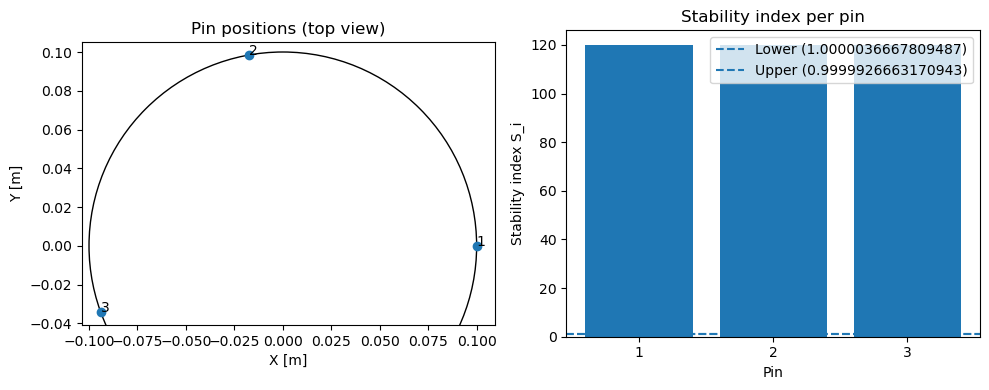

In [15]:
#!/usr/bin/env python3
"""
stability.py

Compute a simple stability index for a three-pin cranial clamp using:
  • Pin forces F_i [N] from force sensors
  • Pin angular positions θ_i [deg] and lever-arms r_i [m] from 3D tracker markers
  • Friction coefficient μ

Includes:
 1. geometry_from_markers: derive R, θ_i, r_i from tracker
 2. compute_stability_index: torque and S_i
 3. classify_stability: label pins
 4. visualize_stability: plot pin geometry and stability indices

Formulas:
  r_i    = R * sin(θ_i / 2)
  τ_i    = μ * F_i * r_i
  S_i    = τ_i / τ_ref
  τ_ref  = μ * F_ref * R * sin(120°/2)

Usage:
  • pip install numpy matplotlib
  • python stability.py
"""

import numpy as np
import matplotlib.pyplot as plt


def geometry_from_markers(skull_center, pin_markers):
    """
    Compute skull radius R, pin separation angles θ_i, and lever-arms r_i.
    """
    vs = [np.array(p) - np.array(skull_center) for p in pin_markers]
    norms = [np.linalg.norm(v) for v in vs]
    R_est = float(np.mean(norms))
    thetas = []
    for i in range(3):
        j = (i + 1) % 3
        cos_theta = np.dot(vs[i], vs[j]) / (norms[i] * norms[j])
        theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))
        thetas.append(np.rad2deg(theta))
    return R_est, thetas, norms


def compute_stability_index(R, mu, forces, thetas_deg):
    """
    Compute per-pin torque τ_i and normalized stability S_i.
    """
    thetas = np.deg2rad(thetas_deg)
    lever_arms = R * np.sin(thetas / 2)
    torques = mu * np.array(forces) * lever_arms
    theta_ref = np.deg2rad(120)
    F_ref = np.mean(forces)
    r_ref = R * np.sin(theta_ref / 2)
    tau_ref = mu * F_ref * r_ref
    S = torques / tau_ref
    return torques, S


def classify_stability(S, thresholds=(0.8, 1.2)):
    """
    Label each S_i as 'stable', 'marginal', or 'critical'.
    """
    labels = []
    for s in S:
        if s > thresholds[1]: labels.append("stable")
        elif s >= thresholds[0]: labels.append("marginal")
        else: labels.append("critical")
    return labels



if __name__ == "__main__":
    # Example usage
    skull_center = [0.0, 0.0, 0.0]
    pin_markers = [
        [0.1,  0.0,  0.0],
        [-0.05, 0.0866, 0.0],
        [-0.05, -0.0866, 0.0]
    ]
    forces = [100, 100, 100]
    mu = 0.3

    R, thetas, lever_arms = geometry_from_markers(skull_center, pin_markers)
    torques, S = compute_stability_index(R, mu, forces, thetas)
    labels = classify_stability(S)

    print(f"Skull radius R = {R:.3f} m")
    for i, (θ, r, τ, s, lab) in enumerate(zip(thetas, lever_arms, torques, S, labels), start=1):
        print(f"Pin {i}: θ={θ:.1f}°, r={r:.3f} m, τ={τ:.3f} N·m, S={s:.2f} → {lab}")

    visualize_stability(R, forces, thetas, S)


Example 1: Symmetric (120°, 100 N each)


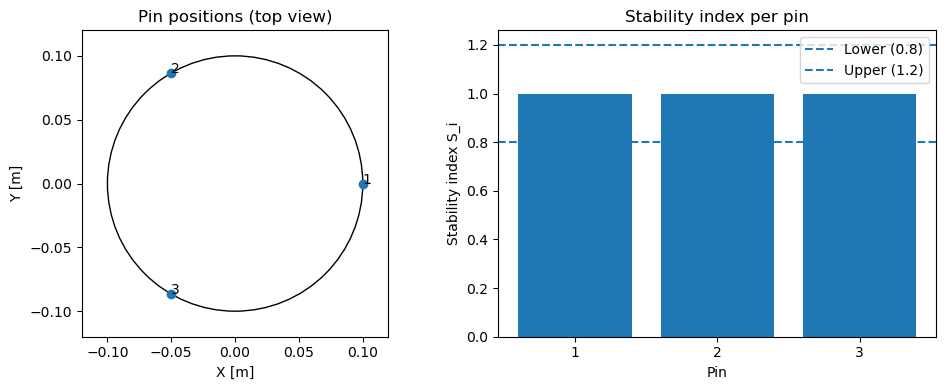

Example 2: Asymmetric (100°/130°/130°, 100 N each)


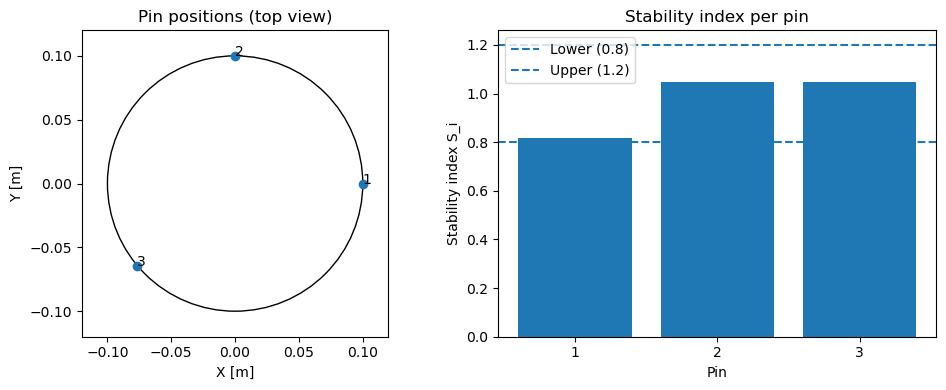

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def compute_stability_index(R, mu, forces, thetas_deg):
    """
    Compute per-pin torque τ_i and normalized stability S_i.
    """
    thetas = np.deg2rad(thetas_deg)
    lever_arms = R * np.sin(thetas / 2)
    torques = mu * np.array(forces) * lever_arms

    theta_ref = np.deg2rad(120)
    F_ref = np.mean(forces)
    r_ref = R * np.sin(theta_ref / 2)
    tau_ref = mu * F_ref * r_ref

    S = torques / tau_ref
    return torques, S

def visualize_stability(R, thetas_deg, S, thresholds=(0.8, 1.2)):
    """
    Plot pin positions on a circle of radius R and a bar chart of stability indices.
    """
    # Compute cumulative absolute angles around the circle
    acc = 0.0
    angles = [0.0]
    for theta in thetas_deg[:-1]:
        acc += theta
        angles.append(acc)
    angles_rad = np.deg2rad(angles)

    # Coordinates of each pin
    xs = R * np.cos(angles_rad)
    ys = R * np.sin(angles_rad)

    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Top-view of pin positions
    circle = plt.Circle((0, 0), R, fill=False)
    ax1.add_artist(circle)
    ax1.scatter(xs, ys)
    for i, (x, y) in enumerate(zip(xs, ys), start=1):
        ax1.text(x, y, str(i))
    ax1.set_aspect('equal', 'box')
    ax1.set_title('Pin positions (top view)')
    ax1.set_xlabel('X [m]')
    ax1.set_ylabel('Y [m]')
    ax1.set_xlim(-R * 1.2, R * 1.2)
    ax1.set_ylim(-R * 1.2, R * 1.2)
    # Bar chart of stability indices
    pins = np.arange(1, len(S) + 1)
    ax2.bar(pins, S)
    ax2.axhline(thresholds[0], linestyle='--', label=f'Lower ({thresholds[0]})')
    ax2.axhline(thresholds[1], linestyle='--', label=f'Upper ({thresholds[1]})')
    ax2.set_xticks(pins)
    ax2.set_xlabel('Pin')
    ax2.set_ylabel('Stability index S_i')
    ax2.set_title('Stability index per pin')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Example cases
R = 0.1  # 100 mm
mu = 0.3

# Example 1: Symmetric configuration
thetas1 = [120, 120, 120]
forces1 = [100, 100, 100]
_, S1 = compute_stability_index(R, mu, forces1, thetas1)
print("Example 1: Symmetric (120°, 100 N each)")
visualize_stability(R, thetas1, S1)

# Example 2: Asymmetric configuration
thetas2 = [90, 130, 130]
forces2 = [100, 100, 100]
_, S2 = compute_stability_index(R, mu, forces2, thetas2)
print("Example 2: Asymmetric (100°/130°/130°, 100 N each)")
visualize_stability(R, thetas2, S2)
